In [8]:
from pairing import get_kdtree_pairs, get_pairs_table_PDSPL, inject_observational_errors, plot_beta_E_vs_D_MC, compute_dissimilarity
from tqdm import tqdm
import pickle
from astropy.cosmology import FlatLambdaCDM
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

In [10]:
########################################################
### Pairing Properties and Titles
########################################################

# --- Deflector properties used for pairing ---
keys_to_pair_deflectors = [
    'z_D',
    'R_e_arcsec',
    'mag_D_i',
    'color_D_gr',
    'color_D_ri',
]

keys_to_pair_deflectors_latex = {
    'z_D': r'$z_{\mathrm{lens}}$',
    'R_e_kpc': r'$R_e$ [kpc]',
    'R_e_arcsec': r'$R_e$ [arcsec]',
    'mag_D_i': r'$m_i$',
    'color_D_gr': r'$m_g - m_r$',
    'color_D_ri': r'$m_r - m_i$',
    'sigma_v_D': r'$\sigma_{v, D}$ [km/s]',
} 

# assign pairing keys for each sample
for key, s in pdspl_samples.items():
    if key == 'lsst_4most_spec-z_sigma_v':
        pairing_keys = ['z_D', 'R_e_arcsec', 'sigma_v_D', 'mag_D_i','color_D_gr','color_D_ri',]
    else:
        pairing_keys = keys_to_pair_deflectors

    s['pairing_keys'] = pairing_keys
    s['pairing_title'] = "Paired w/ kD-Tree in " + ", ".join(
        [keys_to_pair_deflectors_latex[k] for k in pairing_keys]
    )
    s['pairing_keys_latex'] = ', '.join(
        [keys_to_pair_deflectors_latex[k] for k in pairing_keys]
    )

########################################################
## define dissimilarity estimator parameters for each sample
##########################################################
# --- Define which parameters to include in the dissimilarity estimator ---
keys_to_use_for_dissimilarity = [
    "rel_diff_R_e_arcsec",
    "rel_diff_z_D",
    "rel_diff_mag_D_i",
    "rel_diff_color_D_gr",
    "rel_diff_color_D_ri"
]

# --- (optional) Define pretty LaTeX labels for each key ---
key_latex_map = {
    "rel_diff_R_e_arcsec": r"\frac{\Delta R_e}{R_e}",
    "rel_diff_z_D": r"\frac{\Delta z_D}{z_D}",
    "rel_diff_mag_D_i": r"\frac{\Delta m_i}{m_i}",
    "rel_diff_color_D_gr": r"\frac{\Delta c_{gr}}{c_{gr}}",
    "rel_diff_color_D_ri": r"\frac{\Delta c_{ri}}{c_{ri}}"
}

# assign dissimilarity keys for each sample
for key, s in pdspl_samples.items():
    if key == 'lsst_4most_spec-z_sigma_v':
        dissimilarity_keys = [
            "rel_diff_z_D",
            "rel_diff_R_e_arcsec",
            "rel_diff_sigma_v_D"
        ]
    else:
        dissimilarity_keys = keys_to_use_for_dissimilarity

    s['dissimilarity_keys'] = dissimilarity_keys
############################################################

In [11]:
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)
N_realizations = 100

# SET YOUR METRIC HERE ('rms' or 'chi2')
METRIC = 'rms'

# Adjust the plotting threshold based on the metric
# RMS usually ranges from 0 to 0.1. Chi2 (sigma distance) usually ranges from 0 to 3.0+
MAX_DISSIMILARITY = 0.1 if METRIC == 'rms' else 3.0 

mc_results = {k: {'binned_dissim': [], 'binned_scatter': []} for k in pdspl_samples.keys()}

for i_realization in tqdm(range(N_realizations), desc="Realizations"):
    
    for sample_key, s in pdspl_samples.items():
        if len(s["table"]) < 2: continue
            
        # 1. Inject Noise
        table_err = inject_observational_errors(s['table'], sample_key)
        s['table_with_errors'] = table_err
        
        # 2. Find Pairs (Generic)
        indices, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
        
        # 3. Build Tables (PDSPL Specific)
        pairs_table = get_pairs_table_PDSPL(s['table'], indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err, indices, cosmo_true)
        
        # 4. Compute Dissimilarity (Using the new modular function)
        pairs_table_err['dissimilarity'] = compute_dissimilarity(
            pairs_table_err, 
            s['dissimilarity_keys'], 
            method=METRIC
        )
        
        # 5. Store Analysis state
        s["pairs_analysis"] = {
            "pairs_table": pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses": len(s['table']),
            "num_pairs": len(pairs_table),
            "scatter_in_beta_E": np.std(pairs_table['rel_diff_beta_E']),
            "pair_indices": indices
        }
        
        # 6. Binning for MC Results (Using the dynamic MAX_DISSIMILARITY)
        mask = (pairs_table_err['dissimilarity'] < MAX_DISSIMILARITY) & (np.isfinite(pairs_table['rel_diff_beta_E']))
        dissim_masked = pairs_table_err['dissimilarity'][mask]
        delta_beta_masked = pairs_table['rel_diff_beta_E'][mask]
        
        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized = np.digitize(dissim_masked, percentiles)
        
        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bin_mask = (digitized == i)
            run_dissim.append(np.median(dissim_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            run_scatter.append(np.nanstd(delta_beta_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            
        mc_results[sample_key]['binned_dissim'].append(run_dissim)
        mc_results[sample_key]['binned_scatter'].append(run_scatter)



Realizations: 100%|██████████| 100/100 [03:09<00:00,  1.90s/it]


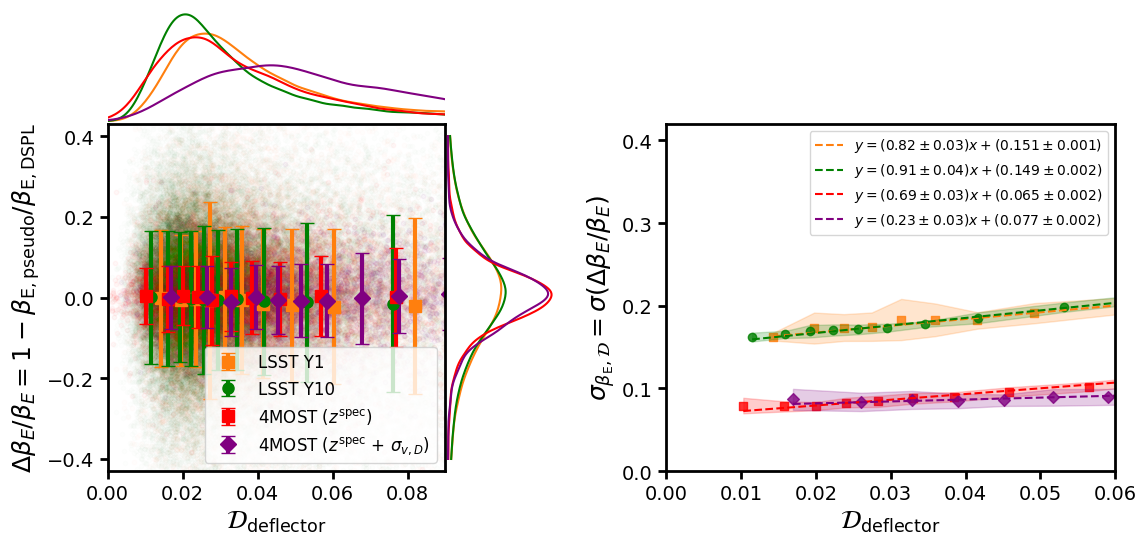

In [12]:
# Plotting
fig_linear = plot_beta_E_vs_D_MC(
    pdspl_samples, 
    mc_results, 
    fit_type='linear', 
    save_path=None,
    show_fit_eqn_label=True
)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner

def plot_reldiff_corner(pdspl_samples, samples_to_plot, key_list, key_latex_labels, 
                        figsize=(14, 14), show_multiple_titles=True, 
                        error_type='asymmetric', title_y_spacing=0.15,
                        custom_ranges=None):
    """
    Generates a combined corner plot for the relative difference properties of multiple samples,
    pulling metadata directly from the provided dictionary.
    """
    # 1. Setup Labels, Truths, and Ranges
    plot_labels = [key_latex_labels.get(k, k) for k in key_list]
    truth_values = [0.0] * len(key_list) 
    
    # NEW: Translate dictionary of ranges into the ordered list corner expects
    if isinstance(custom_ranges, dict):
        # If a key isn't in the dict, default to 0.99 (corner's default for plotting 99% of data)
        corner_range = [custom_ranges.get(k, 0.99) for k in key_list]
    else:
        corner_range = custom_ranges
    
    fig = plt.figure(figsize=figsize)
    
    # Filter valid samples that actually exist in the dictionary
    valid_samples = [s for s in samples_to_plot if s in pdspl_samples]

    # 2. Draw Contours
    for sample_key in valid_samples:
        color = pdspl_samples[sample_key].get('color', '#333333')
        
        table = pdspl_samples[sample_key]['pairs_analysis']['pairs_table_with_errors']
        samples_2d = np.vstack([table[k] for k in key_list]).T
        
        mask = ~np.isnan(samples_2d).any(axis=1)
        samples_2d = samples_2d[mask]
        
        fig = corner.corner(
            samples_2d,
            fig=fig,
            labels=plot_labels,
            range=corner_range,       # Use the newly formatted ordered list
            color=color,
            weights=np.ones(len(samples_2d)) / len(samples_2d),
            smooth=1,
            
            plot_datapoints=False,  
            plot_density=False,     
            fill_contours=True,    
            show_titles=False,      
            
            levels=[0.68, 0.95],    
            hist_kwargs={"density": True, "linewidth": 2, "histtype": "step"},
            contour_kwargs={"linewidths": 2},
            
            truths=truth_values, 
            truth_color="#444444",
            label_kwargs={"fontsize": 16}
        )

    # 3. Stacked Colored Titles
    if show_multiple_titles and valid_samples:
        ndim = len(key_list)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        
        for col_idx, param_key in enumerate(key_list):
            ax = axes[col_idx, col_idx] 
            
            param_label_raw = plot_labels[col_idx]
            param_math_text = param_label_raw.replace('$', '')
            
            for row_idx, sample_key in enumerate(valid_samples):
                color = pdspl_samples[sample_key].get('color', '#333333')
                table = pdspl_samples[sample_key]['pairs_analysis']['pairs_table_with_errors']
                
                samples_1d = np.array(table[param_key])
                samples_1d = samples_1d[~np.isnan(samples_1d)]
                
                if error_type == 'symmetric':
                    mean_val = np.mean(samples_1d)
                    std_val = np.std(samples_1d)
                    title_str = fr"${param_math_text} = {mean_val:.3f} \pm {std_val:.3f}$"
                else:
                    q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
                    lower_err = q50 - q16
                    upper_err = q84 - q50
                    title_str = fr"${param_math_text} = {q50:.3f}^{{+{upper_err:.3f}}}_{{-{lower_err:.3f}}}$"
                
                y_offset = 1.05 + (title_y_spacing * row_idx) 
                
                ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                        ha='center', va='bottom', color=color, fontsize=12)

    # 4. Custom Legend
    legend_handles = []
    for sample_key in valid_samples:
        name = pdspl_samples[sample_key].get('name', sample_key)
        color = pdspl_samples[sample_key].get('color', '#333333')
        
        line = mlines.Line2D([], [], color=color, linewidth=3, label=name)
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure,
        fontsize=16,
        frameon=False
    )

    return fig

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Computer Modern Roman
findfont: Generic family 'serif' not found because none of the follow

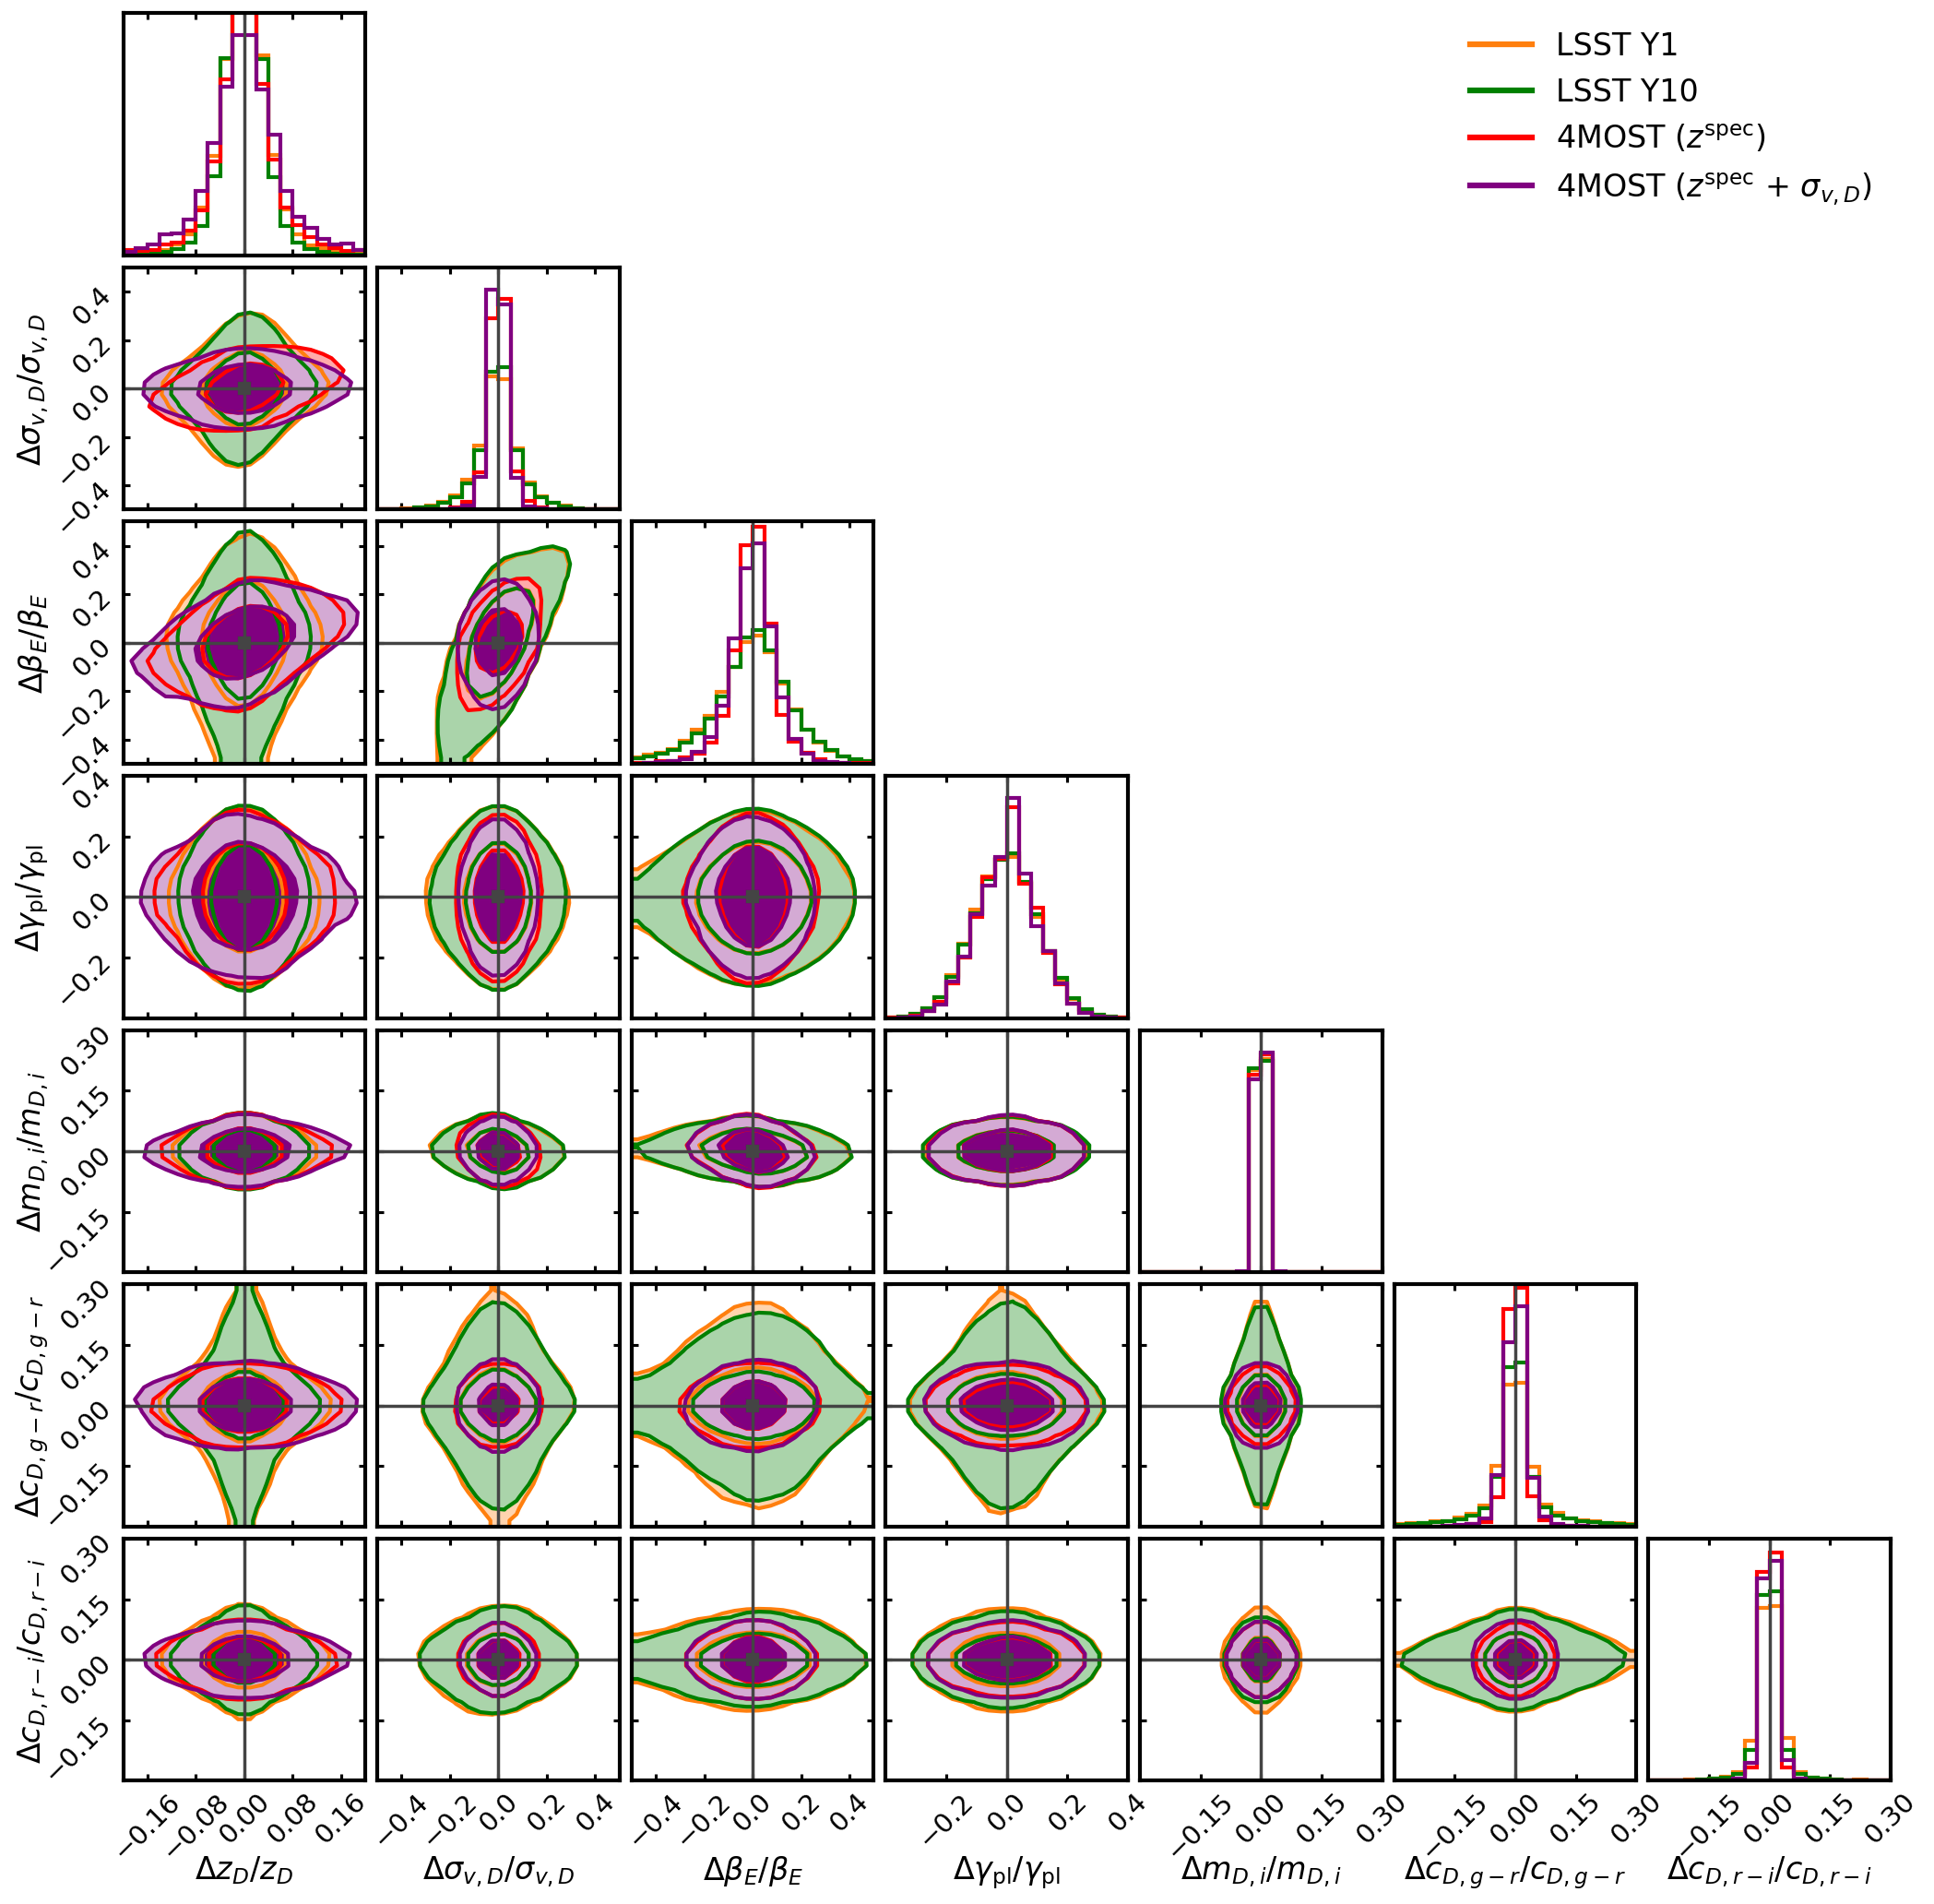

In [18]:
plot_reldiff_corner(
    pdspl_samples=pdspl_samples,
    samples_to_plot=[
        "lsst_y1", 
        "lsst_y10", 
        "lsst_4most_spec-z", 
        "lsst_4most_spec-z_sigma_v"
    ],
     key_list = [
    'rel_diff_z_D',
    'rel_diff_sigma_v_D',
    'rel_diff_beta_E',
    'rel_diff_gamma_pl',
    'rel_diff_mag_D_i',
    'rel_diff_color_D_gr',
    'rel_diff_color_D_ri',
    ],
     key_latex_labels = {
    'rel_diff_z_D': r'$\Delta z_D / z_D$',
    'rel_diff_sigma_v_D': r'$\Delta \sigma_{v, D} / \sigma_{v, D}$',
    'rel_diff_beta_E': r'$\Delta \beta_E / \beta_E$',
    'rel_diff_mag_D_i': r'$\Delta m_{D, i} / m_{D, i}$',
    'rel_diff_color_D_gr': r'$\Delta c_{D, g-r} / c_{D, g-r}$',
    'rel_diff_color_D_ri': r'$\Delta c_{D, r-i} / c_{D, r-i}$',
    'rel_diff_gamma_pl': r'$\Delta \gamma_{\rm pl} / \gamma_{\rm pl}$'
    } ,
    figsize=(14, 14),
    show_multiple_titles=False,
    error_type='asymmetric',
    title_y_spacing=0.15,
    custom_ranges={
    'rel_diff_z_D': (-0.2, 0.2),
    'rel_diff_sigma_v_D': (-0.5, 0.5),
    'rel_diff_beta_E': (-0.5, 0.5),
    'rel_diff_gamma_pl': (-0.4, 0.4),
    'rel_diff_mag_D_i': (-0.3, 0.3),    
    'rel_diff_color_D_gr': (-0.3, 0.3),
    'rel_diff_color_D_ri': (-0.3, 0.3),
    }
);

In [19]:
# print average beta_E scatter for each sample
for sample_key in pdspl_samples.keys():
    scatter = pdspl_samples[sample_key]['pairs_analysis']['scatter_in_beta_E']
    print(f"{sample_key}: Average scatter in beta_E = {scatter:.4f}")

lsst_y1: Average scatter in beta_E = 0.1985
lsst_y10: Average scatter in beta_E = 0.1887
lsst_4most_spec-z: Average scatter in beta_E = 0.1038
lsst_4most_spec-z_sigma_v: Average scatter in beta_E = 0.1005


## lens_ids to send to Phil Holloway

In [34]:
with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

In [66]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM

# 0. Setup: Define inputs
sample_key = 'lsst_y10'
table = pdspl_samples[sample_key]['table']
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

pairing_keys = pdspl_samples[sample_key]['pairing_keys']
dissimilarity_keys = pdspl_samples[sample_key]['dissimilarity_keys']
dissimilarity_cuts = [0.025, 0.033, 0.05]

pairs_table_err = pdspl_samples[sample_key]['pairs_analysis']['pairs_table_with_errors']

# 5. Extract Unique Lens IDs for each cut
lens_ids_dict = {}
num_pairs_dict = {}

for cut in dissimilarity_cuts:
    # Filter for pairs where dissimilarity is GREATER than the cut
    mask_gt_cut = pairs_table_err['dissimilarity'] > cut
    filtered_pairs = pairs_table_err[mask_gt_cut]

    total_pairs = len(pairs_table_err)
    num_pairs = len(filtered_pairs)
    num_pairs_dict[f'dissimilarity_cut_leq_{cut:.3f}'] = total_pairs - num_pairs
    num_pairs_dict[f'dissimilarity_cut_gt_{cut:.3f}'] = num_pairs
    
    # Get all unique indices involved in these bad pairs
    indices_1 = filtered_pairs['index_1']
    indices_2 = filtered_pairs['index_2']
    unique_indices = np.unique(np.concatenate([indices_1, indices_2]))
    
    # Map indices back to the original lens_ids from the base table
    unique_lens_ids = table['lens_id'][unique_indices]
    
    # Store in dictionary
    dict_key = f'dissimilarity_cut_gt_{cut:.3f}'
    lens_ids_dict[dict_key] = unique_lens_ids

    # now also save the complement set of good lenses for this cut
    lens_ids_complement = np.setdiff1d(table['lens_id'], unique_lens_ids)
    dict_key_complement = f'dissimilarity_cut_leq_{cut:.3f}'
    lens_ids_dict[dict_key_complement] = lens_ids_complement


# Print a quick summary of how many lenses were found
for k, v in lens_ids_dict.items():
    print(f"{k}: {len(v)} unique lenses found.")

# save pickle of lens_ids_dict
with open(f'lens_ids_dict_{sample_key}.pkl', 'wb') as f:
    pickle.dump(lens_ids_dict, f)

dissimilarity_cut_gt_0.025: 78110 unique lenses found.
dissimilarity_cut_leq_0.025: 38361 unique lenses found.
dissimilarity_cut_gt_0.033: 57511 unique lenses found.
dissimilarity_cut_leq_0.033: 58960 unique lenses found.
dissimilarity_cut_gt_0.050: 33658 unique lenses found.
dissimilarity_cut_leq_0.050: 82813 unique lenses found.


In [67]:
num_pairs_dict

{'dissimilarity_cut_leq_0.025': 34072,
 'dissimilarity_cut_gt_0.025': 51864,
 'dissimilarity_cut_leq_0.033': 48963,
 'dissimilarity_cut_gt_0.033': 36973,
 'dissimilarity_cut_leq_0.050': 64956,
 'dissimilarity_cut_gt_0.050': 20980}

In [ ]:
from astropy.table import Table
import pickle

lsst_y10_GGLs_table = Table.read(
    "../../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
)

# load pickle of lens_ids_dict
with open(f'lens_ids_dict_{sample_key}.pkl', 'rb') as f:
    loaded_lens_ids_dict = pickle.load(f)

# The pickle file has following structure:
# {
#     'dissimilarity_cut_gt_0.025': array([lens_id_...]),   # 78110 unique lenses for Phil
#     'dissimilarity_cut_leq_0.025': array([lens_id_...]),  # 38361 unique lenses ==> 34072 lens pairs for Paras

#     'dissimilarity_cut_gt_0.033': array([lens_id_...]),   # 57511 unique lenses for Phil
#     'dissimilarity_cut_leq_0.033': array([lens_id_...]),  # 58960 unique lenses ==> 48963 lens pairs for Paras

#     'dissimilarity_cut_gt_0.050': array([lens_id_...]),   # 33658 unique lenses for Phil
#     'dissimilarity_cut_leq_0.050': array([lens_id_...]),  # 82813 unique lenses ==> 64956 lens pairs for Paras
# }

# example to choose lenses with dissimilarity cut greater than 0.033
lsst_y10_GGLs_table_dissimilarity_cut_gt_0_033 = lsst_y10_GGLs_table[np.isin(lsst_y10_GGLs_table['lens_id'], loaded_lens_ids_dict['dissimilarity_cut_gt_0.033'])]

In [65]:
lsst_y10_GGLs_table_dissimilarity_cut_gt_0_033

lens_id,z_D,z_S,theta_E,num_images,radial_dist_S,size_S,mag_S_g,mag_S_g_lensed,mag_D_g,mag_S_r,mag_S_r_lensed,mag_D_r,mag_S_i,mag_S_i_lensed,mag_D_i,mag_S_z,mag_S_z_lensed,mag_D_z,mag_S_y,mag_S_y_lensed,mag_D_y,es_magnification,size_D,surf_bri_mag/arcsec2,sigma_v_D,stellar_mass_D,e1_mass_D,e2_mass_D,e_mass_D,gamma_pl,R_e_kpc,Sigma_half_Msun/pc2,contrast_ratio_g,contrast_ratio_r,contrast_ratio_i,contrast_ratio_z,contrast_ratio_y,snr_g,snr_r,snr_i
bytes13,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object,float64,float64,float64
lens_0_45,1.043564894776167,3.943590463111406,0.9939235612526814,4,0.08028456239023608,0.1126505982457771,24.84908101861113,21.773016732392115,23.788002689655286,24.121191524148898,21.045127237929883,23.033016718124003,24.072717110886543,20.996652824667528,22.256653813156028,23.919079998998555,20.84301571277954,21.35229367920592,23.872994917657607,20.79693063143859,20.84386312990651,16.999091614981733,0.8527432359180878,25.91772091883236,253.7891338345494,507055295820.7063,-0.16301390502556445,0.07868573637104835,0.18101098955571143,1.9319584409030506,6.89547872057362,4109.564304441456,[-5.40143943 -5.36609902 -5.07667501 -4.30643909],[-5.37434296 -5.33900254 -5.04957853 -4.27934261],[-4.64645447 -4.61111405 -4.32169004 -3.55145412],[-3.89573144 -3.86039102 -3.57096702 -2.8007311 ],[-3.43338598 -3.39804556 -3.10862155 -2.33838563],303.80926613944405,570.6761697168475,393.9783109581673
lens_0_105,1.4994644720681405,2.506633358481914,0.5419742735369639,4,0.15872184079125243,0.08107488827315538,25.089457273266536,22.823385409830017,25.06001066585304,24.93738756302417,22.67131569958765,24.870201350257037,24.76981330887857,22.503741445442053,23.9416445839603,24.742670878483377,22.476599015046858,23.21552287001637,24.566683157470482,22.300611294033963,22.700056087813767,8.06173921678553,0.6132672818616209,26.6345518568347,271.6700958608003,605305442531.9102,0.3450048767795045,-0.029499657048876752,0.34626376473382603,2.1408886856470515,5.189789206435685,6925.59567572212,[-6.27949456 -6.04713126 -4.99640065 -3.81616095],[-6.24175496 -6.00939166 -4.95866104 -3.77842134],[-5.48077244 -5.24840914 -4.19767853 -3.01743883],[-4.78179316 -4.54942986 -3.49869925 -2.31845955],[-4.4423141 -4.2099508 -3.15922019 -1.97898049],183.012396348416,212.23748559556486,162.74585650287477
lens_0_245,1.3849368616700397,3.8715876007939283,0.8580672852900454,2,0.21307562088010137,0.04309169399379587,26.40222256912518,23.521926654393617,24.6443318318726,25.774781878501813,22.89448596377025,24.48359350481541,25.74364015945931,22.86334424472775,23.54441125476219,25.603032508443107,22.722736593711545,23.00262118088552,25.55329642378333,22.673000509051768,22.30135668796953,14.194443350356929,0.5618423162240735,25.860809035591114,253.1568763824898,503863042374.9964,-0.04842130106988138,-0.024955602865102518,0.05447388834717794,1.8348236053328306,4.734071980478726,5532.577810286746,[-6.52717248 -4.86658539 nan nan],[-6.99387484 -5.33328775 nan nan],[-6.08583431 -4.42524722 nan nan],[-5.68465189 -4.0240648 nan nan],[-5.03312348 -3.37253639 nan nan],88.1283772778141,148.20195483273594,102.48582505881235
lens_0_305,0.8887062982268876,2.9727932205620204,0.4638651271785879,4,0.18442783614262226,0.0536005330170817,25.875286326192484,23.421524549150938,24.25378387127928,25.774588971805127,23.32082719476358,23.486909531290753,25.62049187204985,23.166730095008305,22.57978295467451,25.507305641405683,23.053543864364137,21.820268688888678,25.527172663304736,23.07341088626319,21.508916874500617,9.58307111061012,0.32955197750909637,24.339235803636907,178.22752412396113,174450027198.59775,-0.14386503984474236,-0.2474701363914615,0.28624922374591316,1.953208101608307,2.558196102309226,5307.6114833104475,[-5.13473023 -4.537